In [27]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Load the dataset
df=pd.read_csv('Live.csv')

In [ ]:
                    #-------Perform EDA-------#

In [ ]:
# Shape of the dataset
df.shape

(7050, 16)

In [4]:
# Cheking the dataset
df.head(3)

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,246675545449582_1649696485147474,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,246675545449582_1649426988507757,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,246675545449582_1648730588577397,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN


In [5]:
# Showing basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   object 
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(9), object(3)
memory 

In [7]:
# Checking any null value
df.isnull().sum()

status_id              0
status_type            0
status_published       0
num_reactions          0
num_comments           0
num_shares             0
num_likes              0
num_loves              0
num_wows               0
num_hahas              0
num_sads               0
num_angrys             0
Column1             7050
Column2             7050
Column3             7050
Column4             7050
dtype: int64

In [8]:
# Finding any duplicated value
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7045    False
7046    False
7047    False
7048    False
7049    False
Length: 7050, dtype: bool

In [9]:
# Here, contain 4 redundant column those column need to drop
df=df.drop(columns=['Column1', 'Column2', 'Column3', 'Column4' ])

In [11]:
# Cheking the shape and summary of the dataset
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   status_id         7050 non-null   object
 1   status_type       7050 non-null   object
 2   status_published  7050 non-null   object
 3   num_reactions     7050 non-null   int64 
 4   num_comments      7050 non-null   int64 
 5   num_shares        7050 non-null   int64 
 6   num_likes         7050 non-null   int64 
 7   num_loves         7050 non-null   int64 
 8   num_wows          7050 non-null   int64 
 9   num_hahas         7050 non-null   int64 
 10  num_sads          7050 non-null   int64 
 11  num_angrys        7050 non-null   int64 
dtypes: int64(9), object(3)
memory usage: 661.1+ KB


In [ ]:
# Now redundant colums have been removed
# Now dataset contain 3 categorical column and 9 numerical column

In [ ]:
        #------Explore three categorical variable-------#

In [14]:
# Explore the status_id column
len(df['status_id'].unique())

6997

In [15]:
# Explore the status_published column
len(df['status_published'].unique())

6913

In [17]:
# Explore the status_type column
len(df['status_type'].unique())
df['status_type'].value_counts()

status_type
photo     4288
video     2334
status     365
link        63
Name: count, dtype: int64

In [ ]:
# In this dataset contain total 7050 samples. 
# So, status_id and status_published act as unique identifier for these samples
# So, both will drop

In [ ]:
# Drop status_id and status_published column
df=df.drop(columns=['status_id', 'status_published'])

In [19]:
# Declare feature Variable
X=df

In [21]:
# Convert Categorical Variable into integer value
maping_dict={
    'photo':0,
    'video':1,
    'status':2,
    'link':3
}
df['status_type'] = df['status_type'].map(maping_dict)

In [26]:
# Again show the dataset
df.head(4)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   status_type    7050 non-null   int64
 1   num_reactions  7050 non-null   int64
 2   num_comments   7050 non-null   int64
 3   num_shares     7050 non-null   int64
 4   num_likes      7050 non-null   int64
 5   num_loves      7050 non-null   int64
 6   num_wows       7050 non-null   int64
 7   num_hahas      7050 non-null   int64
 8   num_sads       7050 non-null   int64
 9   num_angrys     7050 non-null   int64
dtypes: int64(10)
memory usage: 550.9 KB


In [28]:
# Perform feature Scaling
cols=X.columns
scaler=MinMaxScaler()
X=scaler.fit_transform(X)
X=pd.DataFrame(X, columns=[cols])

In [40]:
# Train the model
wcss=[]

for i in range(1,11):
    km=KMeans()
    km.fit_predict(X)
    wcss.append(km.inertia_)

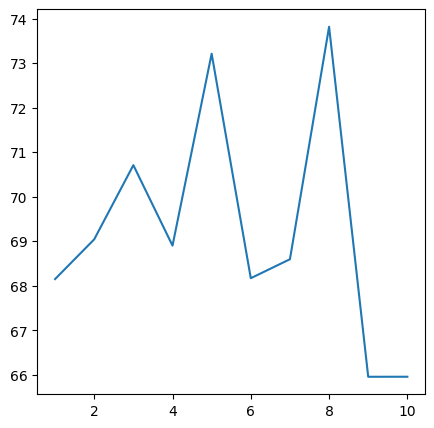

In [41]:
# Now create a plot to sohow elbow point
# Best k value findout
plt.figure(figsize=(5,5))
plt.plot(range(1,11), wcss)

In [ ]:
# Here, deficult to find elbow point

In [ ]:
# Value of inertia
km.inertia_

94.62380493279187

In [42]:
# Now again train the model with best k=5

# Create a kmeans object
km=KMeans(n_clusters=5)
y_cluster=km.fit_predict(X)

In [43]:
# Show the y_cluster
X[y_cluster==4].shape
print(set(y_cluster))

{np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)}


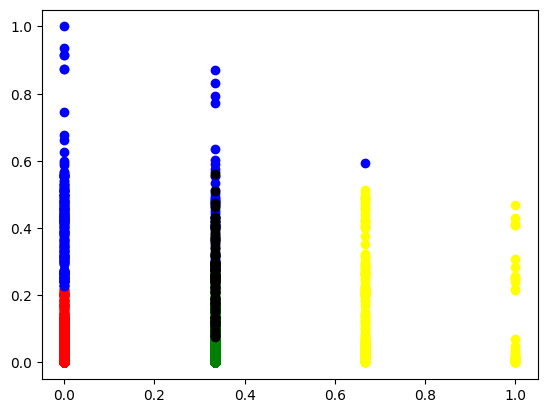

In [44]:
# Now create a scater plot to visualize cluster
colors = ['red', 'green', 'blue', 'yellow', 'black']
for i in range(5):
    plt.scatter(X.iloc[y_cluster==i, 0], X.iloc[y_cluster==i, 1], color=colors[i])


In [ ]:
# K_mean clustering is not good algorithm for this dataset.
# Try DBscan